<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-49-random-forest-intuition-code?scriptVersionId=350590387" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🌲 ML 49 — Random Forest | Intuition & Code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.datasets import make_classification
from sklearn.datasets import make_circles

In [2]:
X, y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])

df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,3.055705,2.692895,2.326866,2.246457,0.018043,1
1,0.649979,0.496119,1.271069,0.829728,-0.874061,1
2,0.823742,0.599499,0.385732,0.858513,-3.444626,1
3,-0.947266,-0.395310,-0.438276,3.175171,-1.280110,0
4,-0.509622,-1.329413,0.175391,2.978370,-1.957517,0


In [4]:
# function for row sampling

def sample_rows(df, percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
# function for feature sampling

def sample_features(df, percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [6]:
# function for combined sampling

def combined_sampling(df, row_percent, col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [7]:
df1 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_16/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [8]:
df2 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_16/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [9]:
df3 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_16/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [10]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col4', 'target'], dtype='object')
Index(['col3', 'col1', 'target'], dtype='object')
Index(['col3', 'col5', 'target'], dtype='object')


In [11]:
clf1 = DecisionTreeClassifier(random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = DecisionTreeClassifier(random_state=42)

In [12]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier(random_state=42)

[Text(0.27364864864864863, 0.9444444444444444, 'x[1] <= -1.0\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.10810810810810811, 0.8333333333333334, 'x[0] <= -1.772\ngini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.19087837837837837, 0.8888888888888888, 'True  '),
 Text(0.05405405405405406, 0.7222222222222222, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.16216216216216217, 0.7222222222222222, 'x[0] <= -0.344\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.10810810810810811, 0.6111111111111112, 'x[1] <= -1.093\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.05405405405405406, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.16216216216216217, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.21621621621621623, 0.6111111111111112, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.4391891891891892, 0.8333333333333334, 'x[1] <= -0.696\ngini = 0.469\nsamples = 40\nvalue = [25, 15]'),
 Text(0.3564189189189189, 0.8888888888888888, '  False'),
 Te

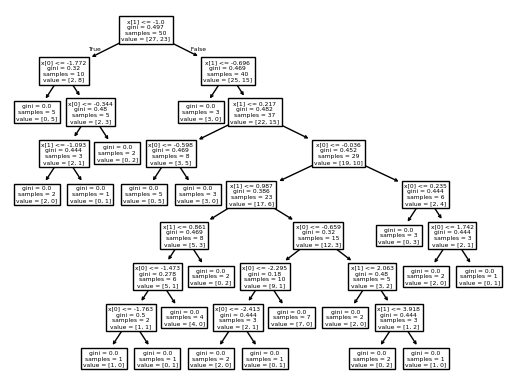

In [13]:
from sklearn.tree import plot_tree

plot_tree(clf1)

[Text(0.45454545454545453, 0.9285714285714286, 'x[1] <= 0.388\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.36363636363636365, 0.7857142857142857, 'x[0] <= -0.061\ngini = 0.367\nsamples = 33\nvalue = [25, 8]'),
 Text(0.40909090909090906, 0.8571428571428572, 'True  '),
 Text(0.18181818181818182, 0.6428571428571429, 'x[1] <= -0.707\ngini = 0.111\nsamples = 17\nvalue = [16, 1]'),
 Text(0.09090909090909091, 0.5, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.2727272727272727, 0.5, 'x[0] <= -1.079\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.18181818181818182, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.36363636363636365, 0.35714285714285715, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.5454545454545454, 0.6428571428571429, 'x[0] <= 0.063\ngini = 0.492\nsamples = 16\nvalue = [9, 7]'),
 Text(0.45454545454545453, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.6363636363636364, 0.5, 'x[0] <= 0.652\ngini = 0.426\nsamples = 1

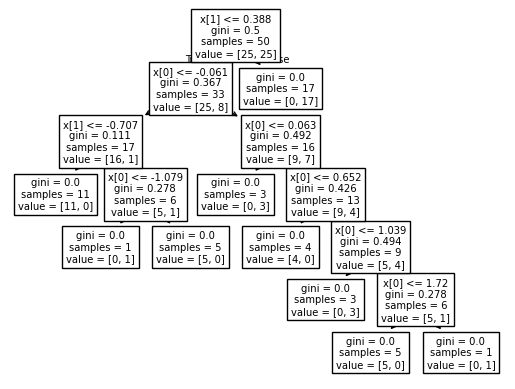

In [14]:
plot_tree(clf2)

[Text(0.5, 0.9375, 'x[0] <= 0.585\ngini = 0.48\nsamples = 50\nvalue = [30, 20]'),
 Text(0.3, 0.8125, 'x[1] <= -1.097\ngini = 0.257\nsamples = 33\nvalue = [28, 5]'),
 Text(0.4, 0.875, 'True  '),
 Text(0.2, 0.6875, 'x[0] <= -0.773\ngini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.1, 0.5625, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3, 0.5625, 'x[1] <= -1.951\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.2, 0.4375, 'x[1] <= -2.731\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.1, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3, 0.3125, 'x[0] <= -0.284\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.2, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.1875, 'x[0] <= -0.037\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.3, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.4375, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.4, 0.6875, 'gini = 

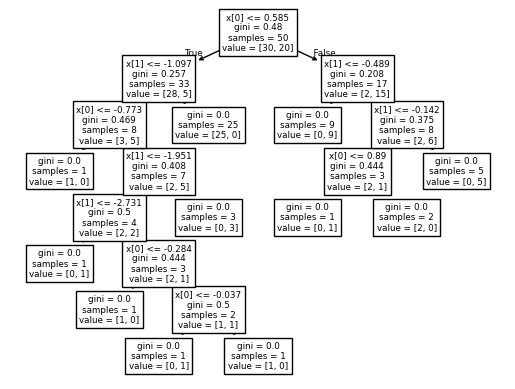

In [15]:
plot_tree(clf3)

In [16]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [17]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [18]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

# Random Forest Demo

In [19]:
np.random.seed(42)

X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

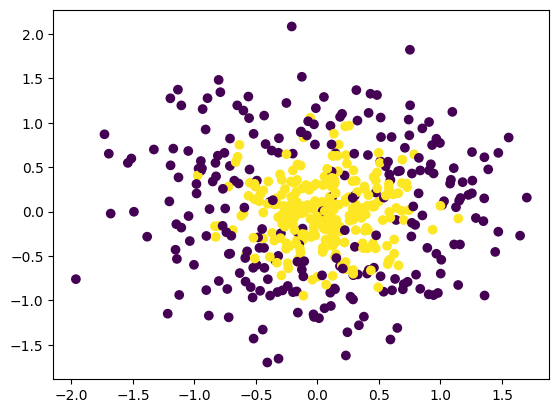

In [20]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

# Bagging Vs Random Forest